# Random Forest - Regressie
## Plus: Een extra analyse van verschillende regressiemethoden

## De (artificiële) Data

We zijn net aangenomen door een tunnelboorbedrijf dat röntgenstralen gebruikt in een poging om de dichtheid van gesteente te bepalen. Idealiter stelt dit hen in staat om de boorkoppen van hun apparatuur te verwisselen voordat ze door het gesteente heen moeten boren!

<img src='../../DATA/boring.jpg' height=400>

Ze hebben ons enkele laboratoriumtestresultaten gegeven van de signaalsterkte die in nHz terugkeerde naar hun sensoren voor verschillende geteste gesteentedichtheden (in kg/m³). Je zult merken dat het bijna een sinusgolfachtige relatie heeft, waarbij de signaalsterkte oscilleert op basis van de dichtheid. We willen nagaan welk model werkt op dergelijke dataset, om in het veld een terugkerend signaal te kunnen oppikken en op basis daarvan een verwachte densiteit van het gesteente te kunnen voorspellen.  

Net als bij Lineaire Regressie, moet ons model een output voorspellen binnen een verwachte range van rebound signal (0 - 100 nHz).  We zullen de output van verschillende modellen visualiseren, en zo verschillende regressiemodellen met elkaar kunnen vergelijken.  Sommige modellen kunnen een vloeiende output leveren, terwijl andere modellen een getrapte output geven.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../DATA/rock_density_xray.csv")

In [3]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [4]:
df.columns=['Signal',"Density"] # de kolommen een andere naam geven voor de eenvoud

<Axes: xlabel='Signal', ylabel='Density'>

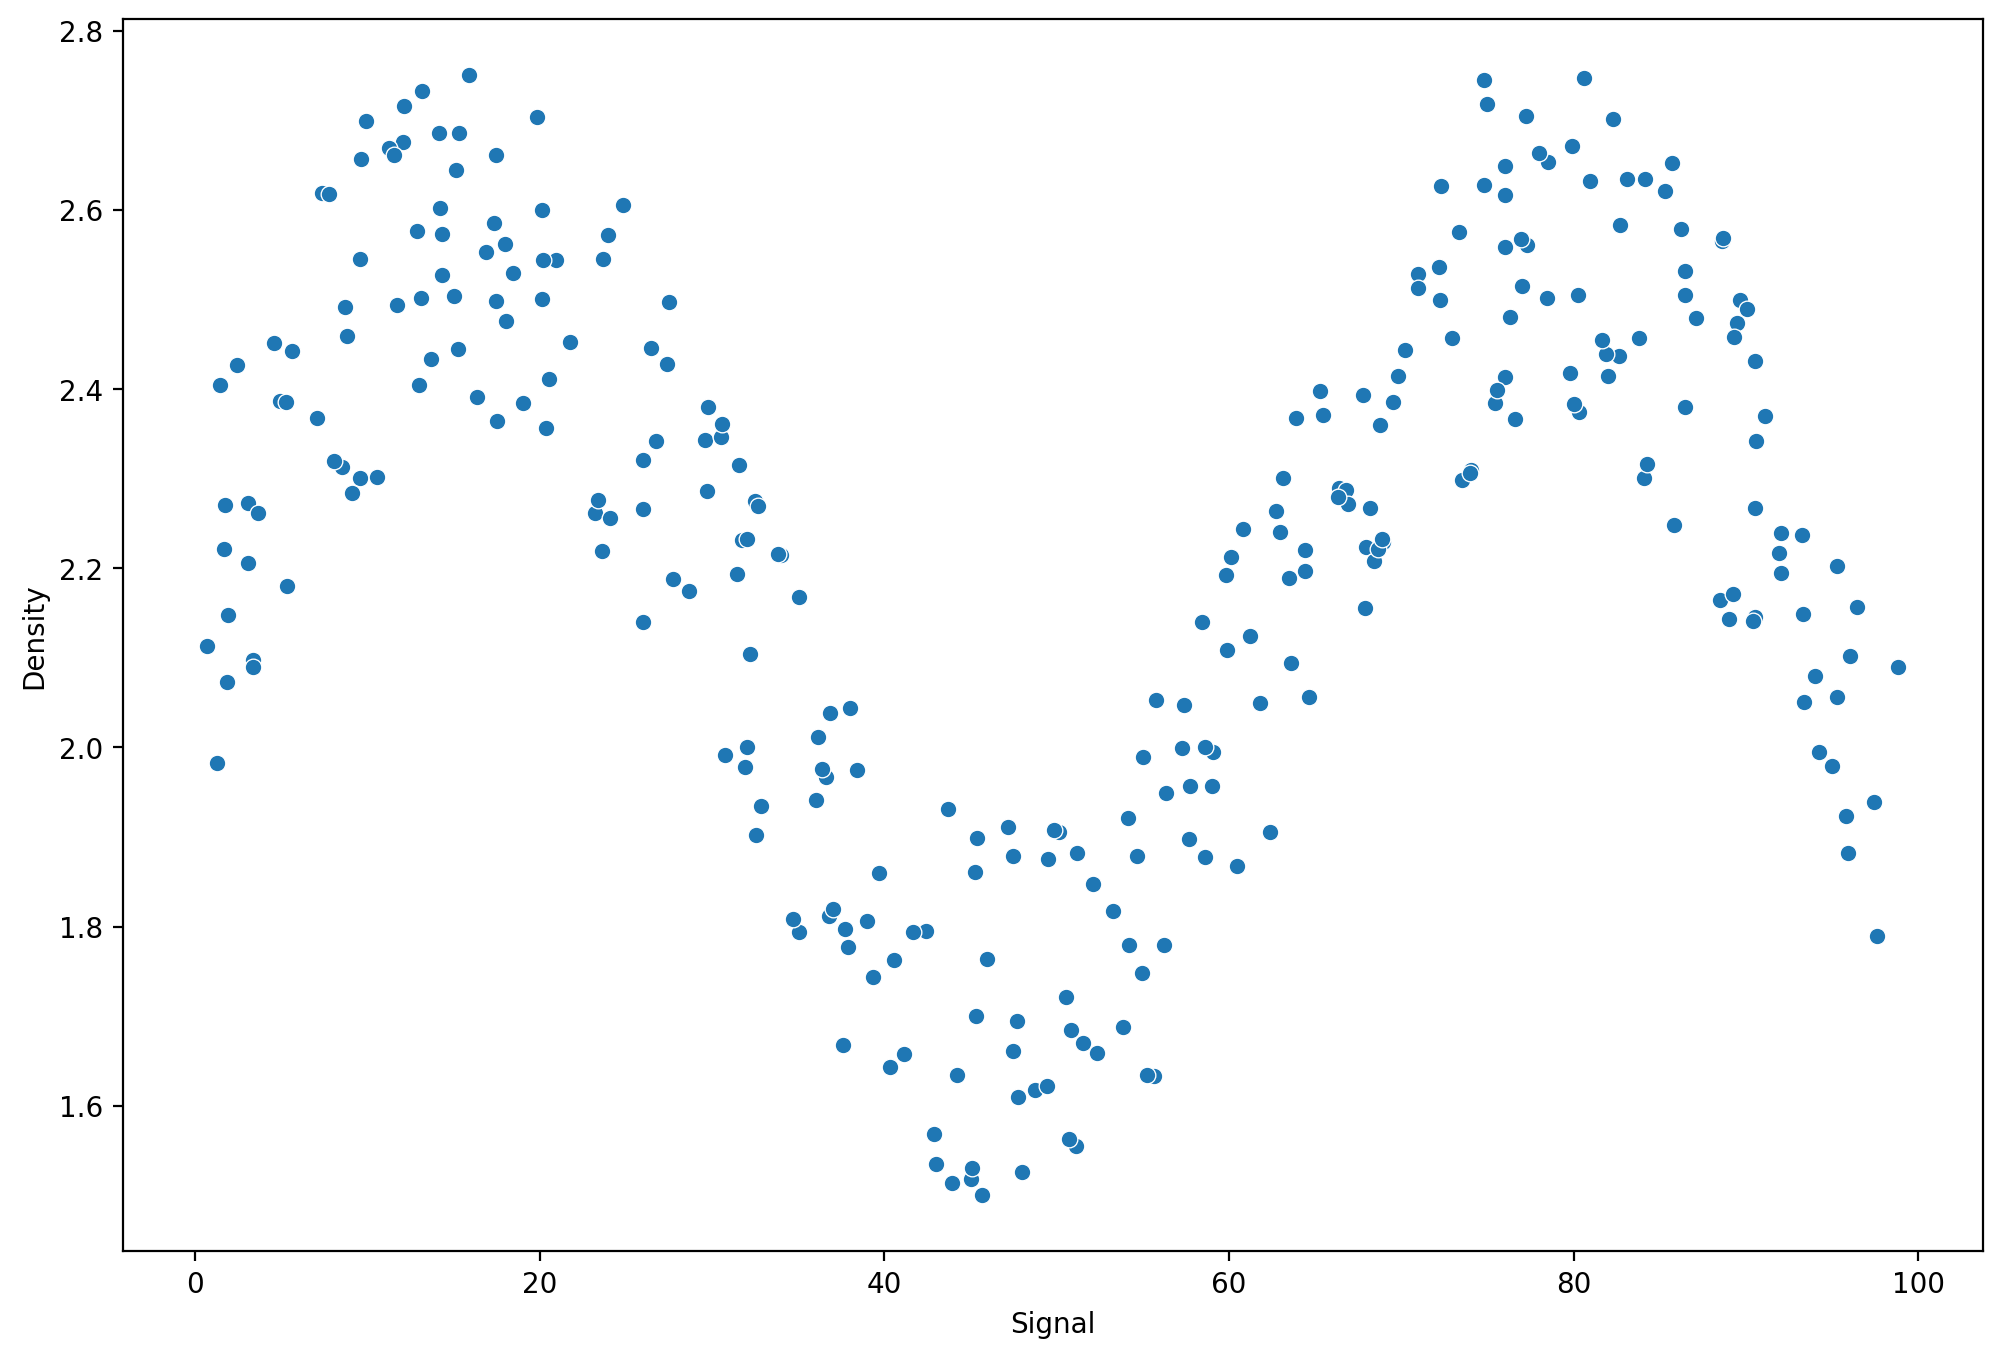

In [5]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

## Train-test split van de Data

We splitsen de data om een Test te hebben set voor bepaling van de performantie van ons model na het trainen 

In [6]:
X = df['Signal'].values.reshape(-1,1)
y = df['Density']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

de dataset is eenvoudig; scalen is niet nodig want we hebben maar 1 feature...

-----

# Eerste model: Lineaire Regressie

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr_model = LinearRegression()

In [11]:
lr_model.fit(X_train,y_train)

LinearRegression()

In [12]:
lr_preds = lr_model.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [14]:
np.sqrt(mean_squared_error(y_test,lr_preds))  # rmse

0.2570051996584629

In [15]:
mean_absolute_error(y_test, lr_preds)

0.211198973318633

Dit ziet er niet zo slecht uit; een fout van ongeveer 10%!  
Hoe ziet de fit eruit?

In [16]:
signal_range = np.arange(0,100)

In [17]:
lr_output = lr_model.predict(signal_range.reshape(-1,1))

In [18]:
lr_output

array([2.22028446, 2.22028673, 2.22028899, 2.22029126, 2.22029353,
       2.22029579, 2.22029806, 2.22030032, 2.22030259, 2.22030485,
       2.22030712, 2.22030938, 2.22031165, 2.22031391, 2.22031618,
       2.22031844, 2.22032071, 2.22032297, 2.22032524, 2.2203275 ,
       2.22032977, 2.22033204, 2.2203343 , 2.22033657, 2.22033883,
       2.2203411 , 2.22034336, 2.22034563, 2.22034789, 2.22035016,
       2.22035242, 2.22035469, 2.22035695, 2.22035922, 2.22036148,
       2.22036375, 2.22036602, 2.22036828, 2.22037055, 2.22037281,
       2.22037508, 2.22037734, 2.22037961, 2.22038187, 2.22038414,
       2.2203864 , 2.22038867, 2.22039093, 2.2203932 , 2.22039546,
       2.22039773, 2.22039999, 2.22040226, 2.22040453, 2.22040679,
       2.22040906, 2.22041132, 2.22041359, 2.22041585, 2.22041812,
       2.22042038, 2.22042265, 2.22042491, 2.22042718, 2.22042944,
       2.22043171, 2.22043397, 2.22043624, 2.2204385 , 2.22044077,
       2.22044304, 2.2204453 , 2.22044757, 2.22044983, 2.22045

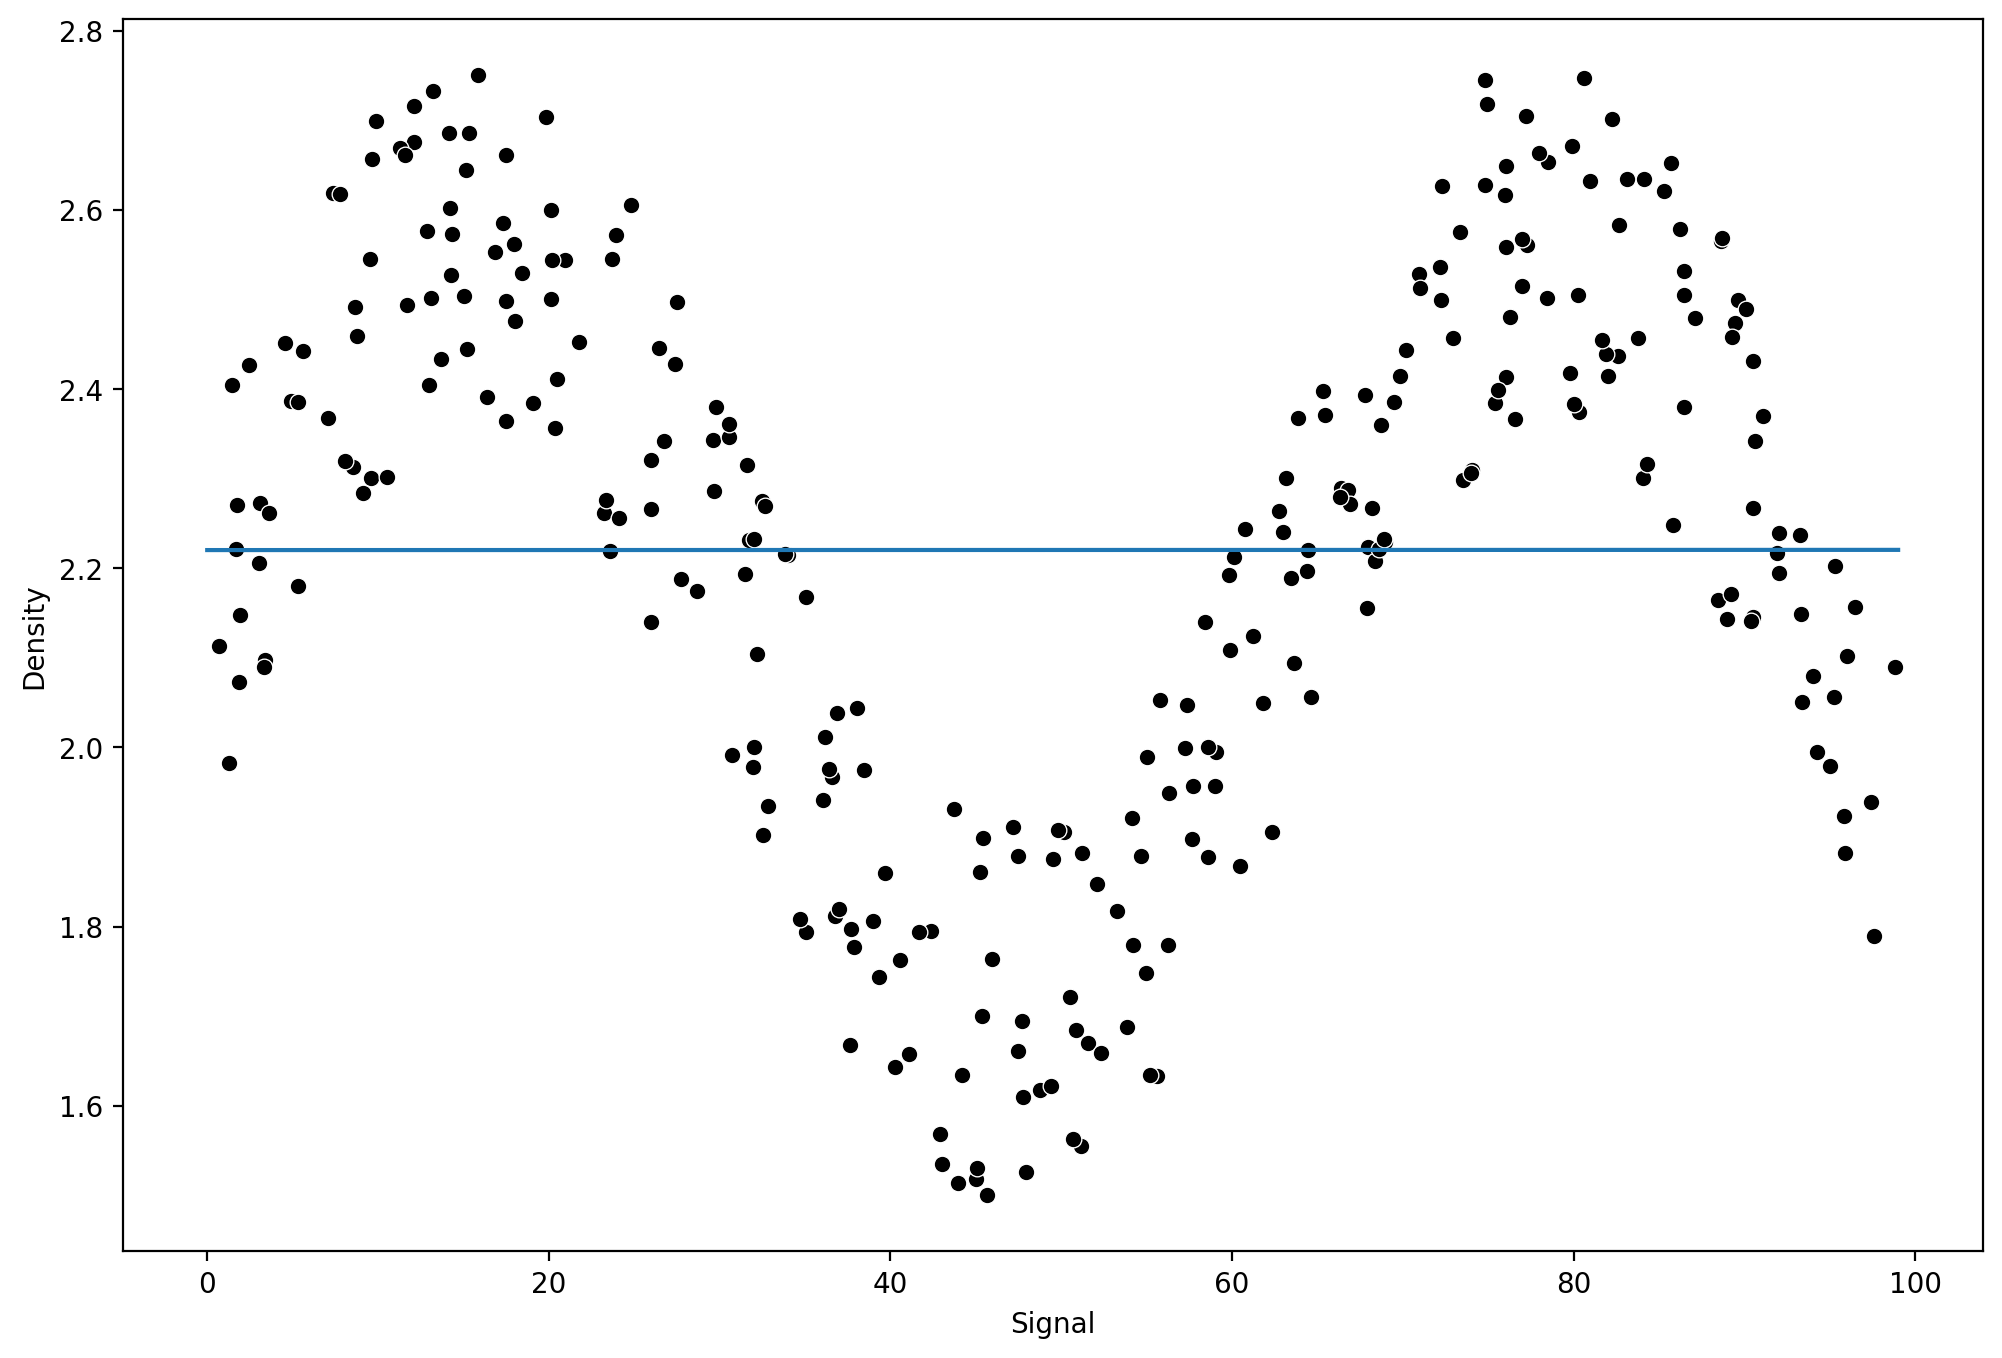

In [19]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df,color='black')
plt.plot(signal_range,lr_output)

Op basis van de performance metrics zag het er niet slecht uit, maar na visualisatie zien we dat Lineaire regressie geen goede optie voor deze dataset...  Indien je deze dataset niet kon plotten, dan kon je dit zien via de voorspellingen of via de residuals...

---

# Polynomiale Regressie

## Poging met een Polynomiaal Regressie Model

Lineaire regressie was gewoon een rechte lijn...  Laat ons even proberen met een polynoom.  Bedenk dat we ons in de gunstige situatie bevinden dat we onze resultaten van y vs x eenvoudig kunnen visualiseren.   

## Helper functie om Modellen te runnen

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
def run_model(model,X_train,y_train,X_test,y_test):
    # Fitten van het Model
    model.fit(X_train,y_train)
    
    # Bereken de Metrics    
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    print(f'MAE : {mae}')
    print(f'RMSE : {rmse}')
    
    # Plot de resultaten van het model binnen de signaal range
    signal_range = np.arange(0,100)
    output = model.predict(signal_range.reshape(-1,1))
        
    plt.figure(figsize=(12,6),dpi=150)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')
    plt.plot(signal_range,output)

MAE : 0.211198973318633
RMSE : 0.2570051996584629


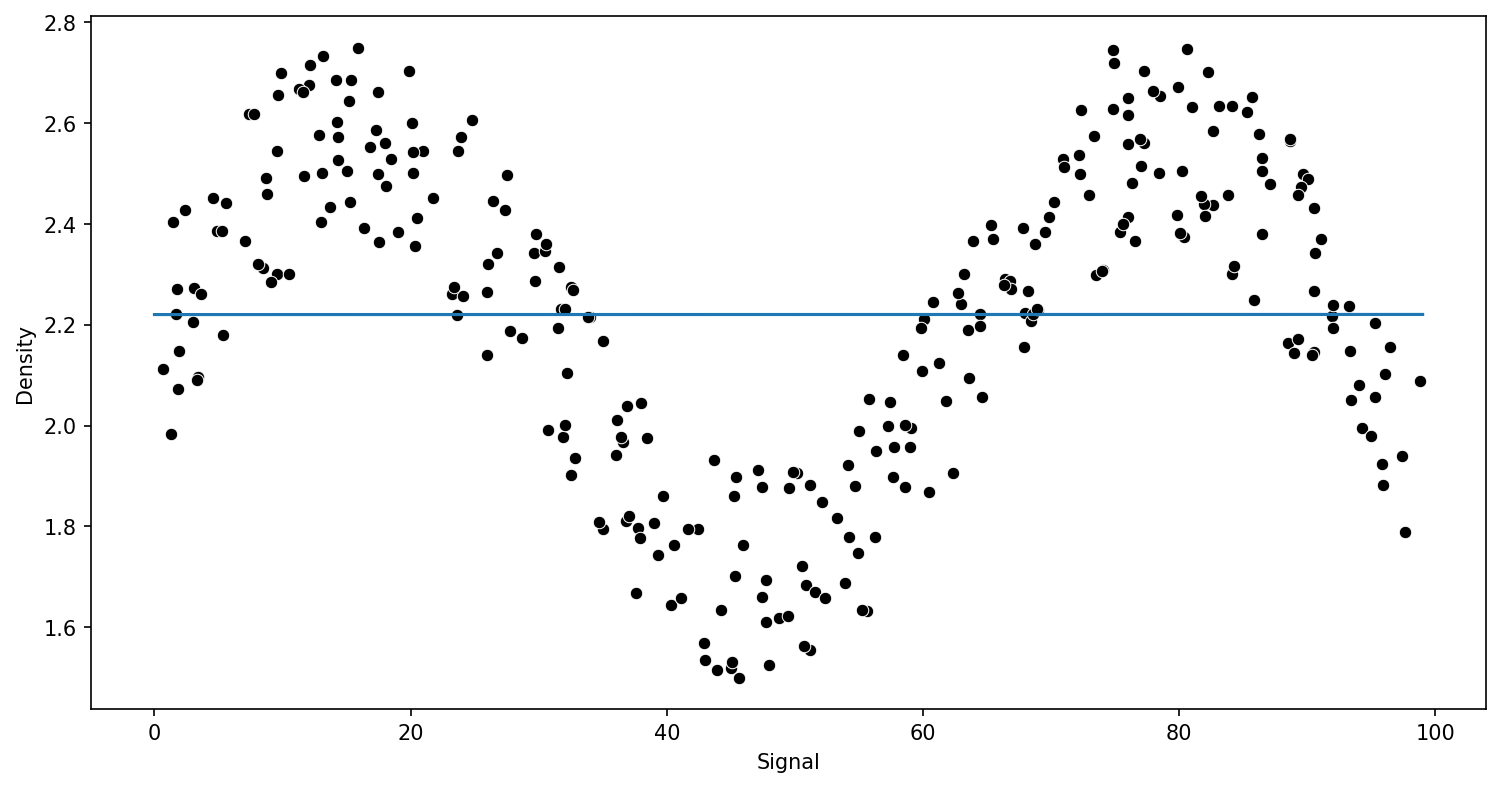

In [22]:
model = LinearRegression()
run_model(model,X_train,y_train,X_test,y_test)

## Pipeline voor Poly Ordes

In [23]:
from sklearn.pipeline import make_pipeline

# make_pipeline is een functie in de scikit-learn bibliotheek (vaak aangeduid als sklearn), een populaire bibliotheek voor machine 
# learning in Python. Het doel van make_pipeline is om een reeks stappen te creëren en te combineren in een enkel model. 
# Elk van deze stappen is meestal een transformer (zoals een scaler of een feature selector) en eindigt met een estimator 
# (zoals een classifier of regressor).

In [24]:
from sklearn.preprocessing import PolynomialFeatures

In [25]:
pipe = make_pipeline(PolynomialFeatures(2),LinearRegression())  
# je geeft in een pipeline de stappen mee die je wil uitvoeren: 
# eerst maken we PolynomialFeatures, dan LinearRegression

MAE : 0.22903105443511168
RMSE : 0.28173095637255463


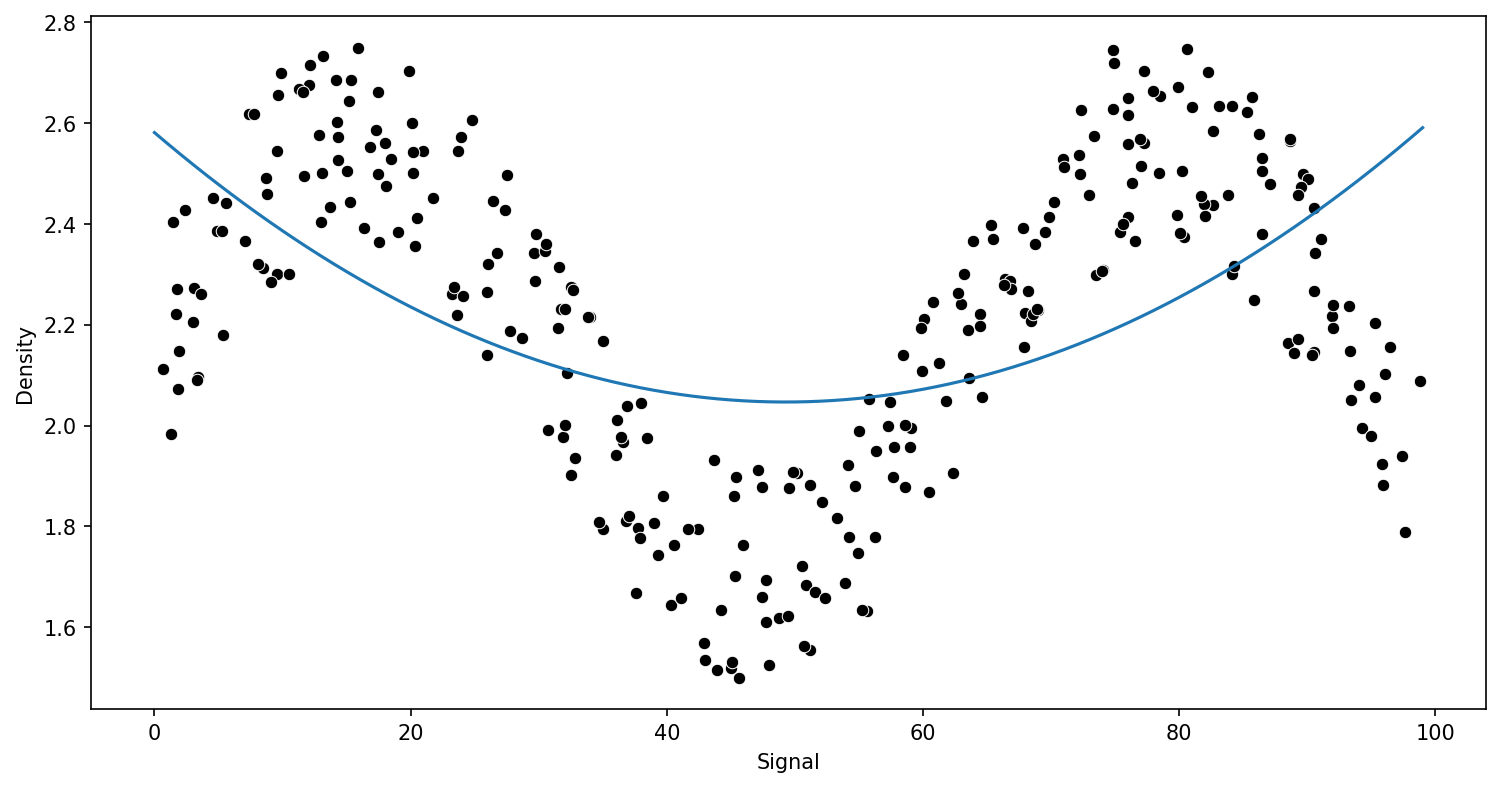

In [26]:
run_model(pipe,X_train,y_train,X_test,y_test)

## Vergelijken van verschillende order van Polynomen

MAE : 0.11969114915429506
RMSE : 0.13807435129205278


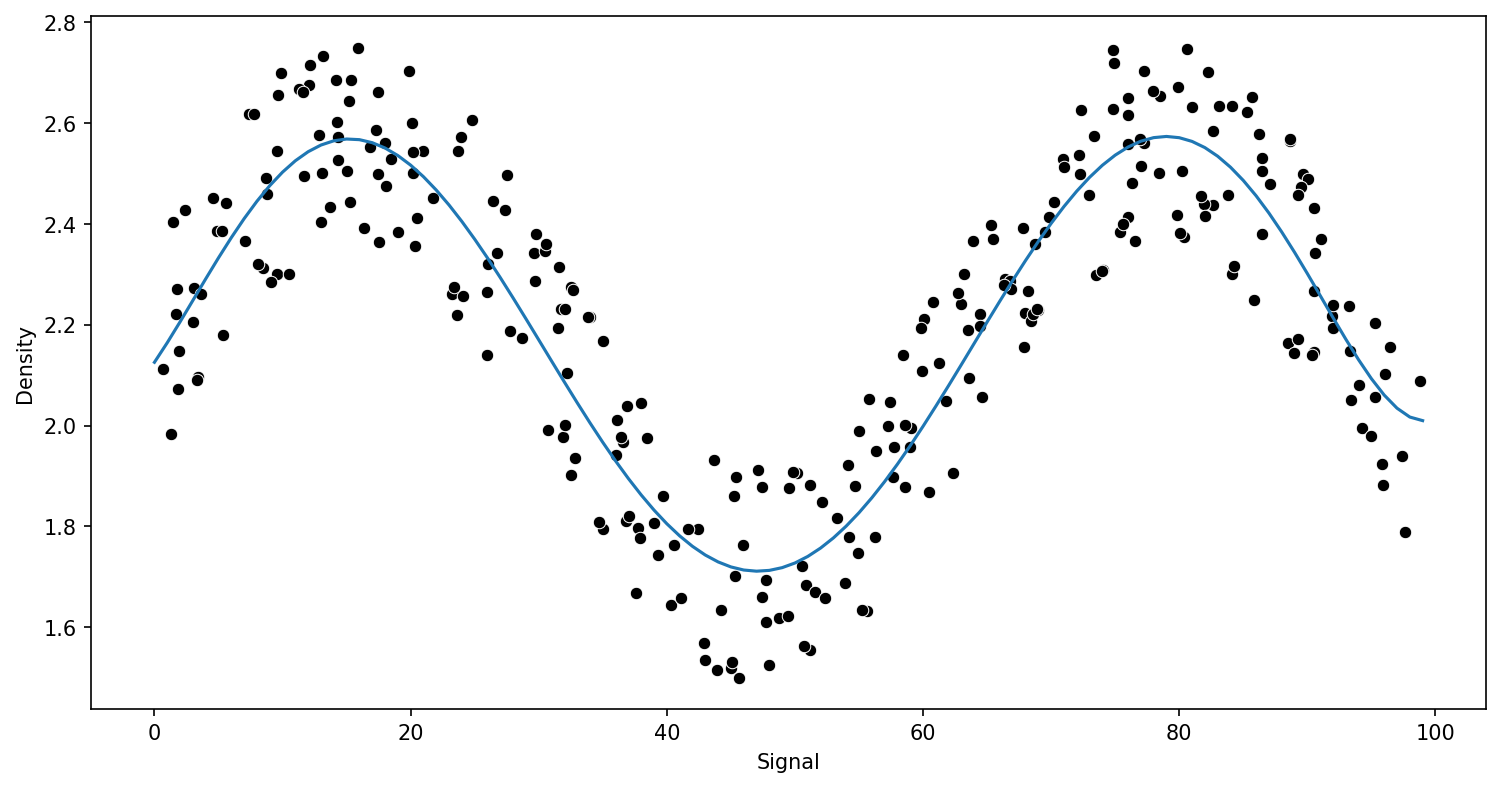

In [27]:
# bij Polynomial regressie hebben we nog een stap voor ons model, namelijk het maken van de polynoom.  Deze extra
# stap verpakken we samen met het model in een pipe.
pipe = make_pipeline(PolynomialFeatures(6),LinearRegression())
run_model(pipe,X_train,y_train,X_test,y_test)

Als we zeker zijn dat de range altijd tussen 0 en 100 blijft, dan zou een graad 6 kunnen werken!  Voorbij een range van 100 weten we niet hoe dit model zich zal gedragen, dus willen we een robuuster model...

----

## KNN Regressie

In [28]:
from sklearn.neighbors import KNeighborsRegressor

MAE : 0.11877297474442378
RMSE : 0.1523487028635337
MAE : 0.12198383614100558
RMSE : 0.13730685016923647
MAE : 0.11635971693292672
RMSE : 0.13277855732740926
MAE : 0.1207030971917154
RMSE : 0.1397499127378895


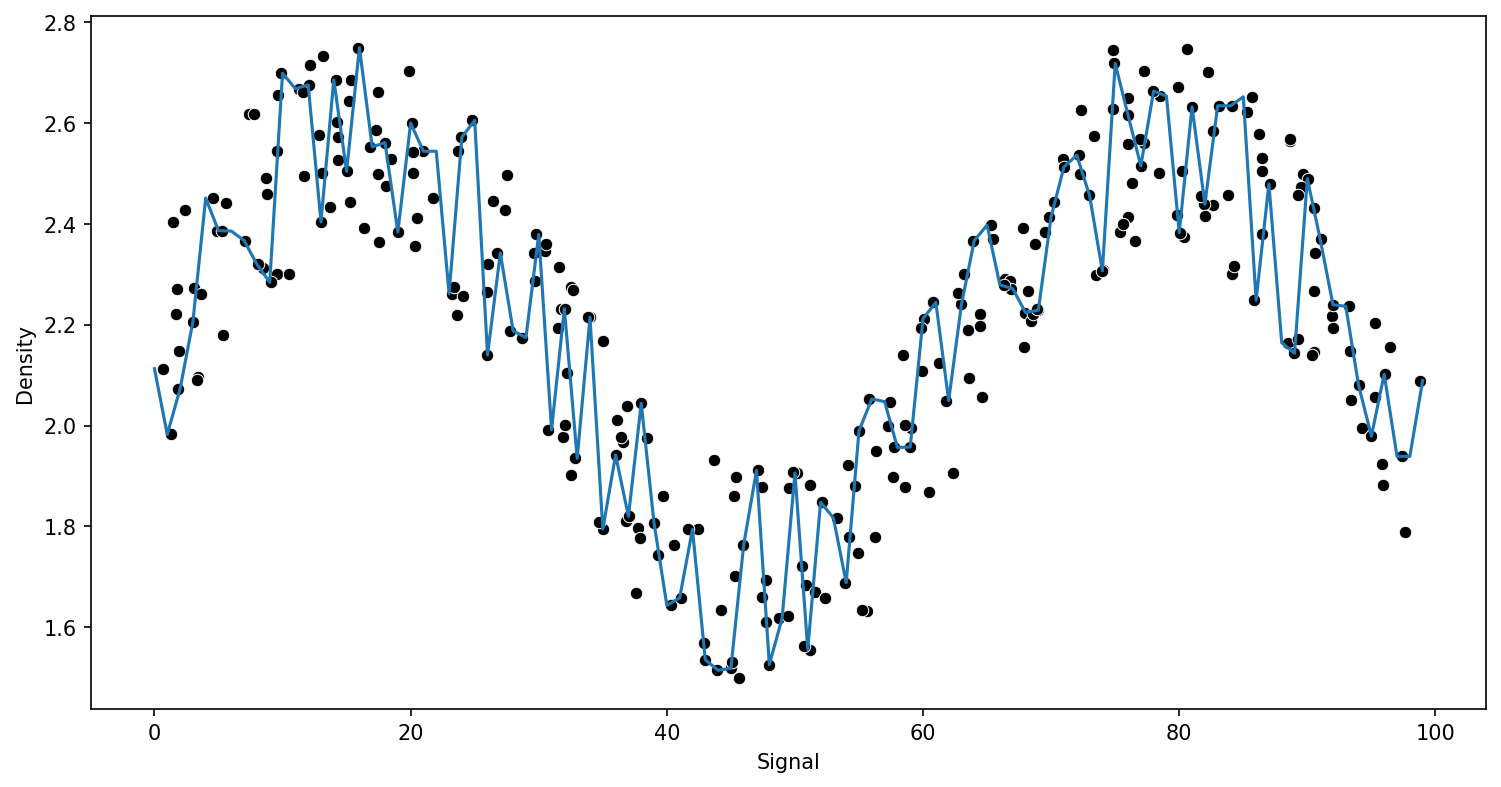

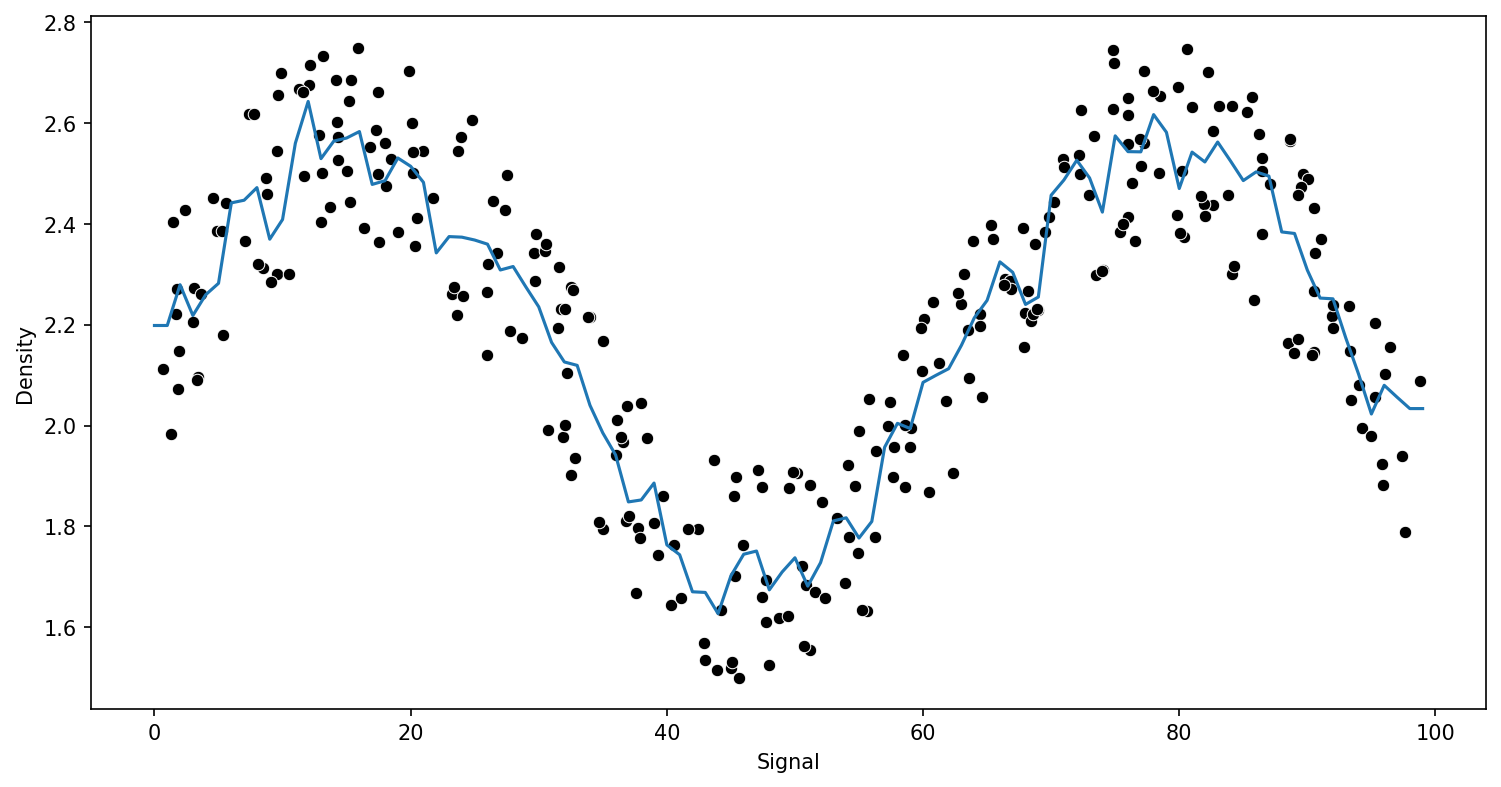

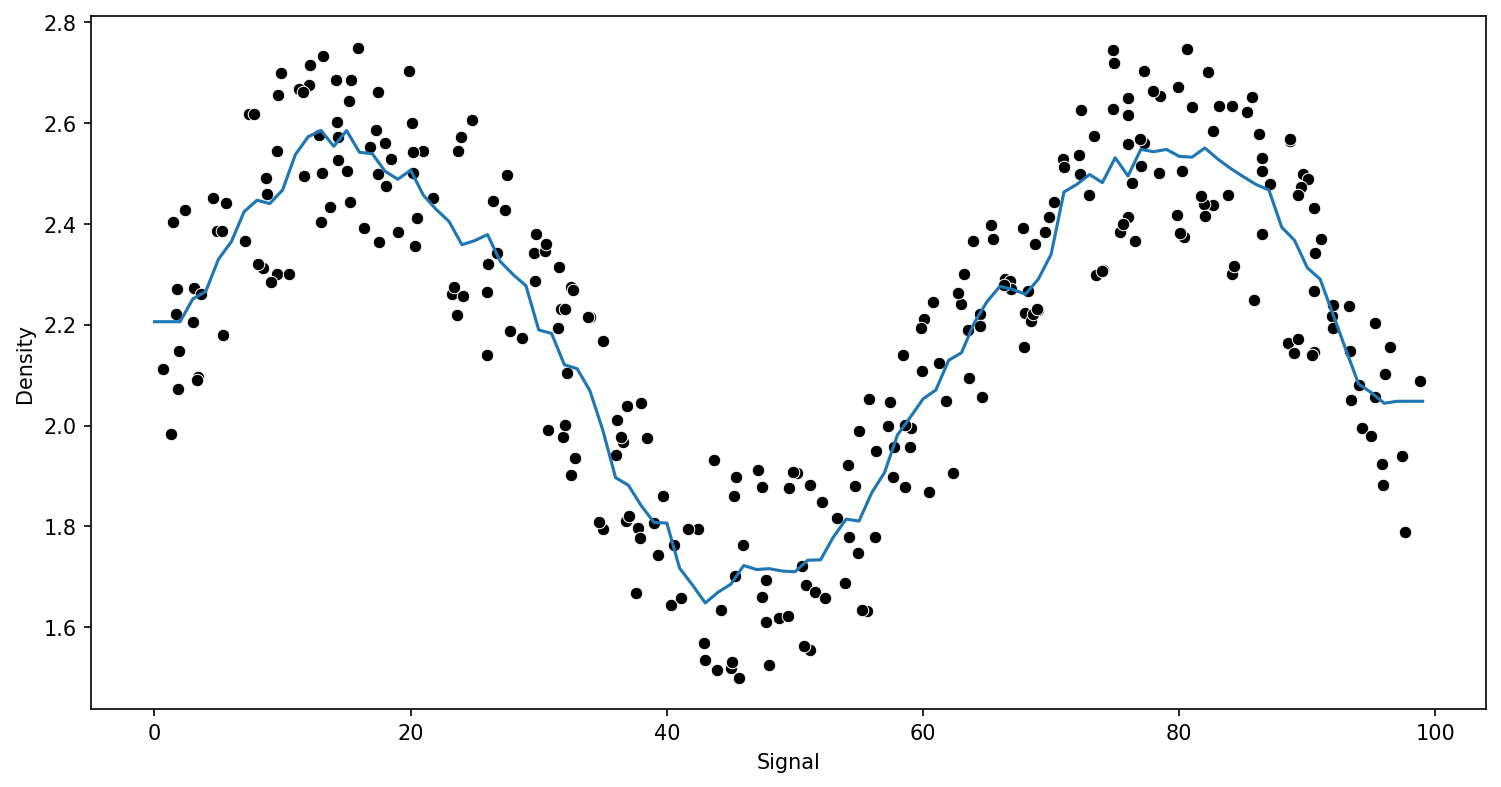

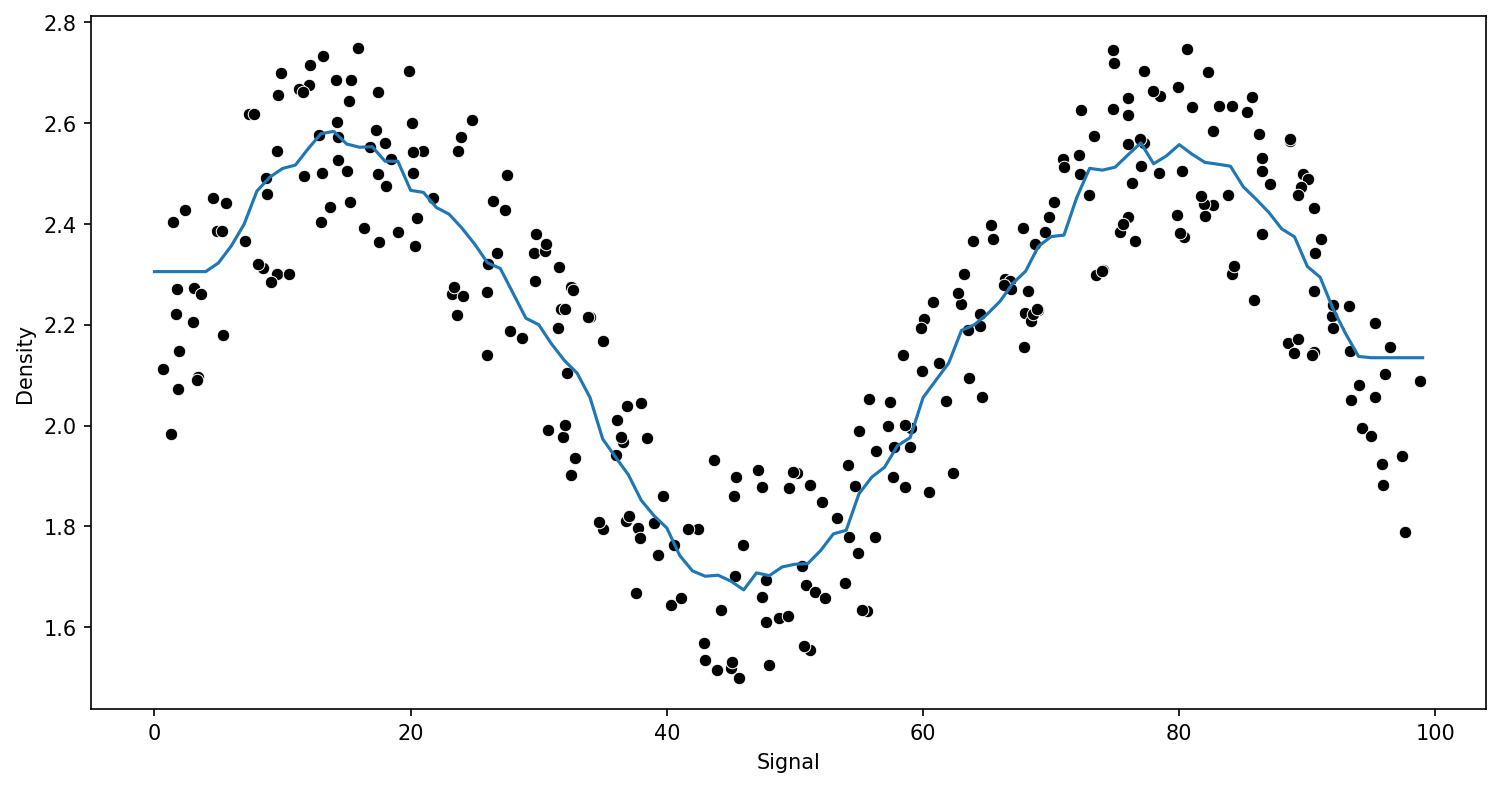

In [29]:
preds = {}
k_values = [1,5,10,20]
for n in k_values:    # we willen een goede K value kiezen.
    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model,X_train,y_train,X_test,y_test)

Bij K=1 wordt de curve gevolgd, maar wordt veel ruis opgepikt.  Wanneer wordt uitgemiddeld met een hogere K, gaat de lijn al iets minder op en neer.

---
## Decision Tree Regressie

In [30]:
from sklearn.tree import DecisionTreeRegressor

MAE : 0.11877297474442378
RMSE : 0.1523487028635337


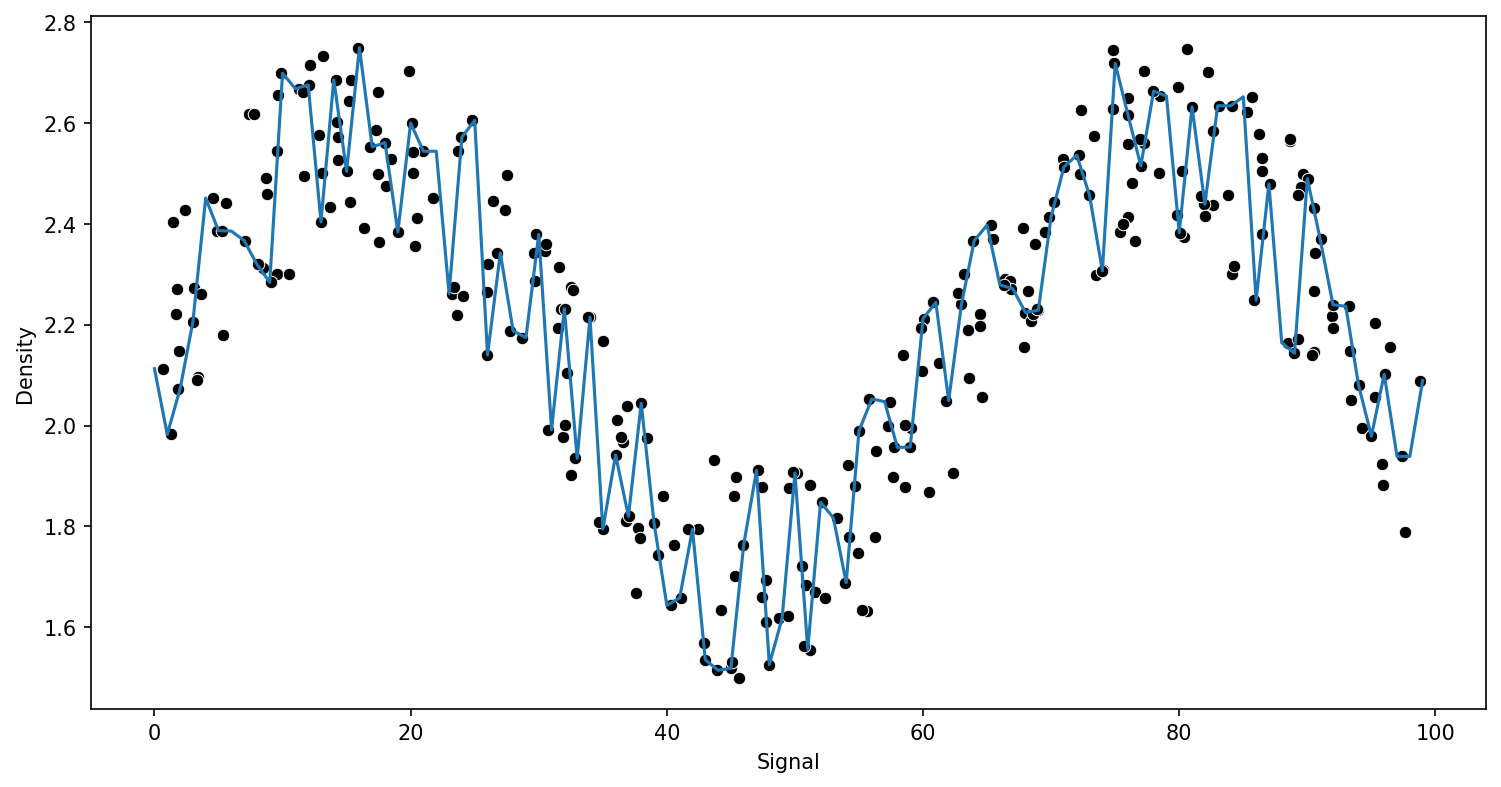

In [31]:
model = DecisionTreeRegressor()  # we hebben maar 1 feature dus we passen niet veel aan inzake Hyperparameters.

run_model(model,X_train,y_train,X_test,y_test)

Het gedrag bij 1 Decision Tree is vergelijkbaar met dat van een KNN Regressor met K=1.  Het pikt zeer veel ruis op.

In [32]:
model.get_n_leaves()

270

----

## Support Vector Regressie (zien we later)

In [33]:
from sklearn.svm import SVR

In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
param_grid = {'C':[0.01,0.1,1,5,10,100,1000],'gamma':['auto','scale']}
svr = SVR()

In [36]:
grid = GridSearchCV(svr,param_grid)

MAE : 0.10854210121349125
RMSE : 0.12646999302047557


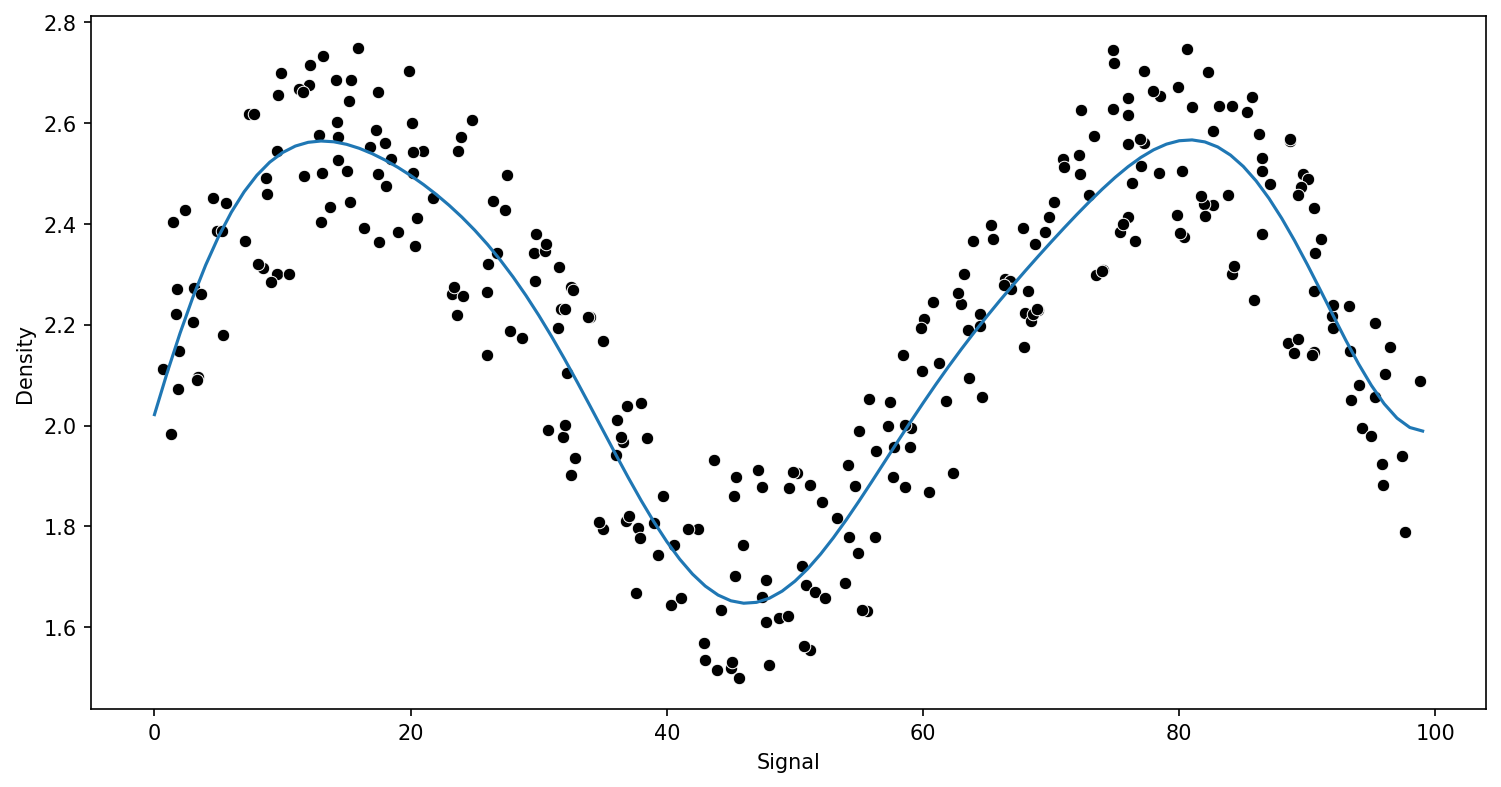

In [37]:
run_model(grid,X_train,y_train,X_test,y_test)

In [38]:
grid.best_estimator_

SVR(C=1000)

---

## Random Forest Regressie

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
# help(RandomForestRegressor)

MAE : 0.11429049447152155
RMSE : 0.13532436200187797
MAE : 0.10905962425269926
RMSE : 0.13481018098191985
MAE : 0.11077341163887769
RMSE : 0.13380139843604727


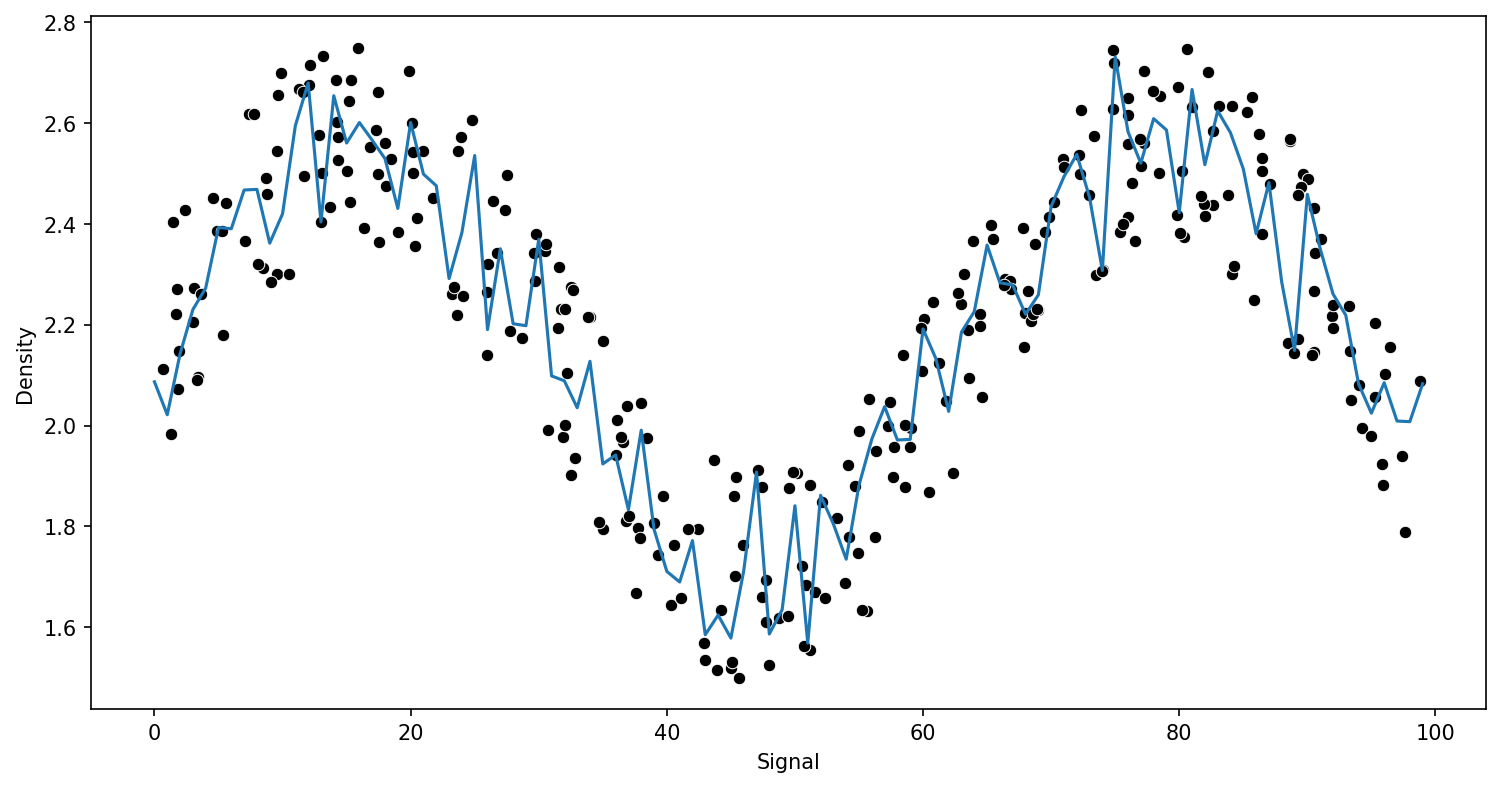

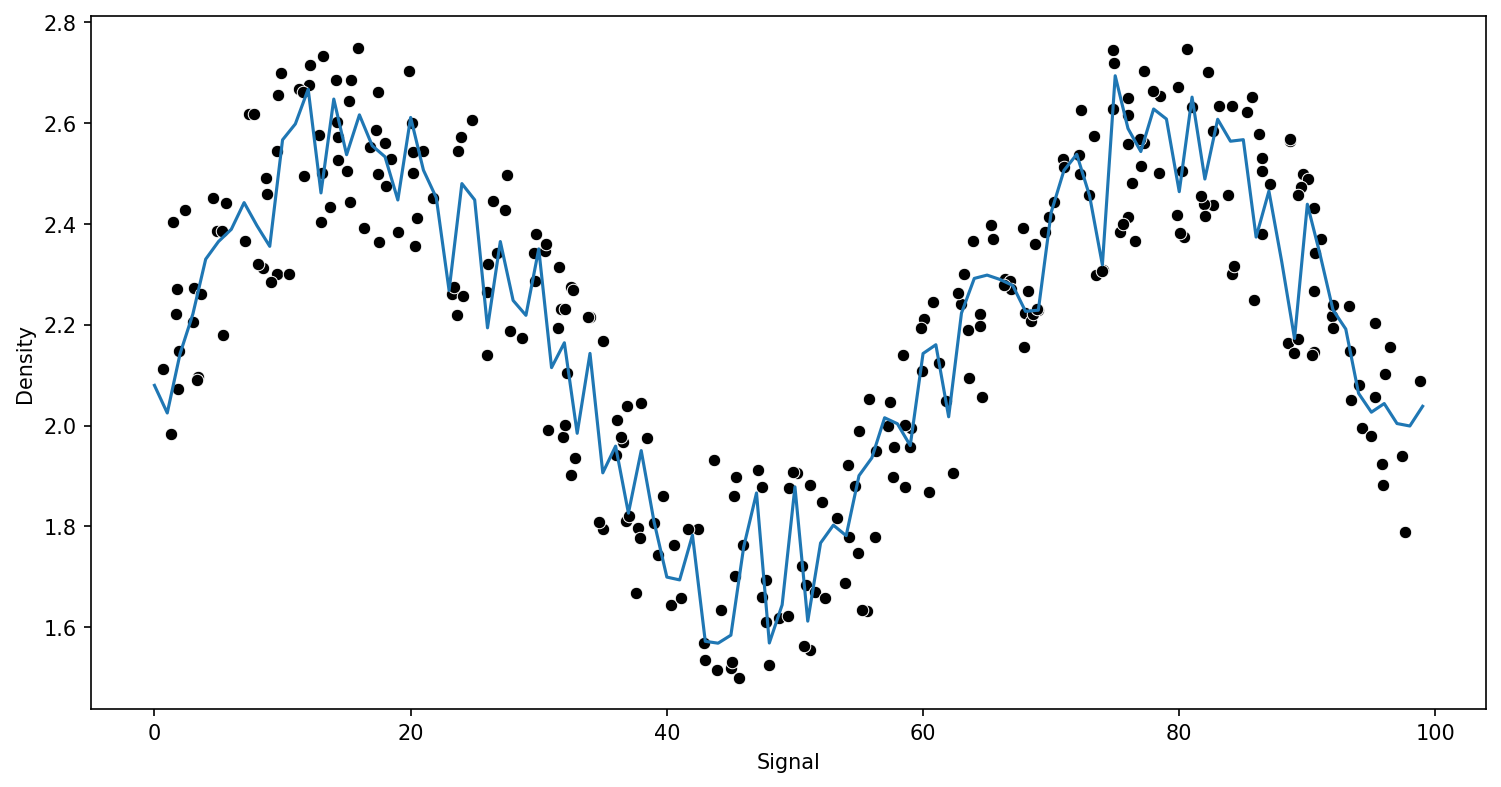

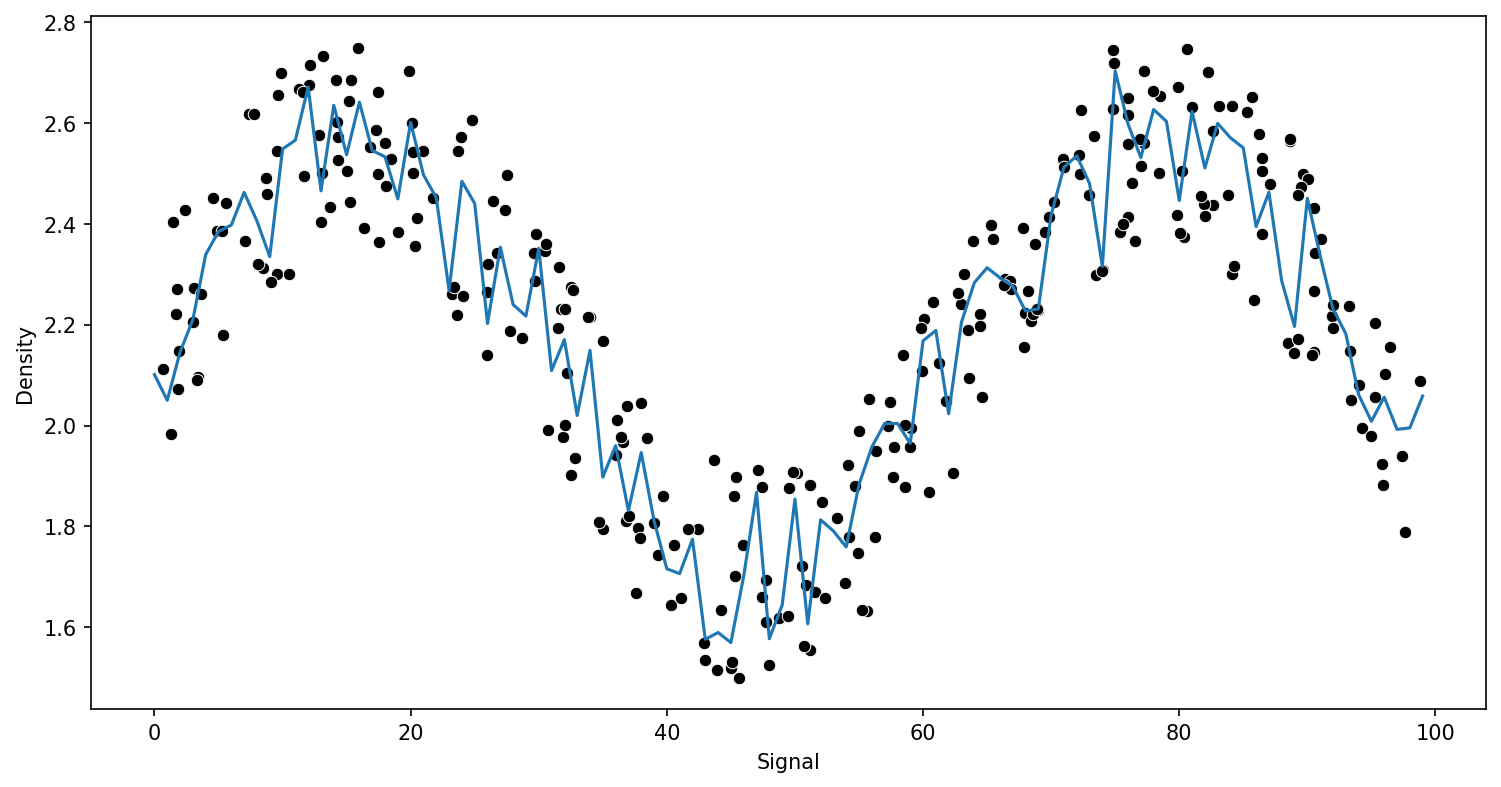

In [41]:
trees = [10,50,100]
for n in trees:    
    model = RandomForestRegressor(n_estimators=n)    
    run_model(model,X_train,y_train,X_test,y_test)

## Gradient Boosting (zien we later)

We behandelen dit in detail de komende lessen

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

In [43]:
# help(GradientBoostingRegressor)

MAE : 0.11318284854800689
RMSE : 0.13294148649584667


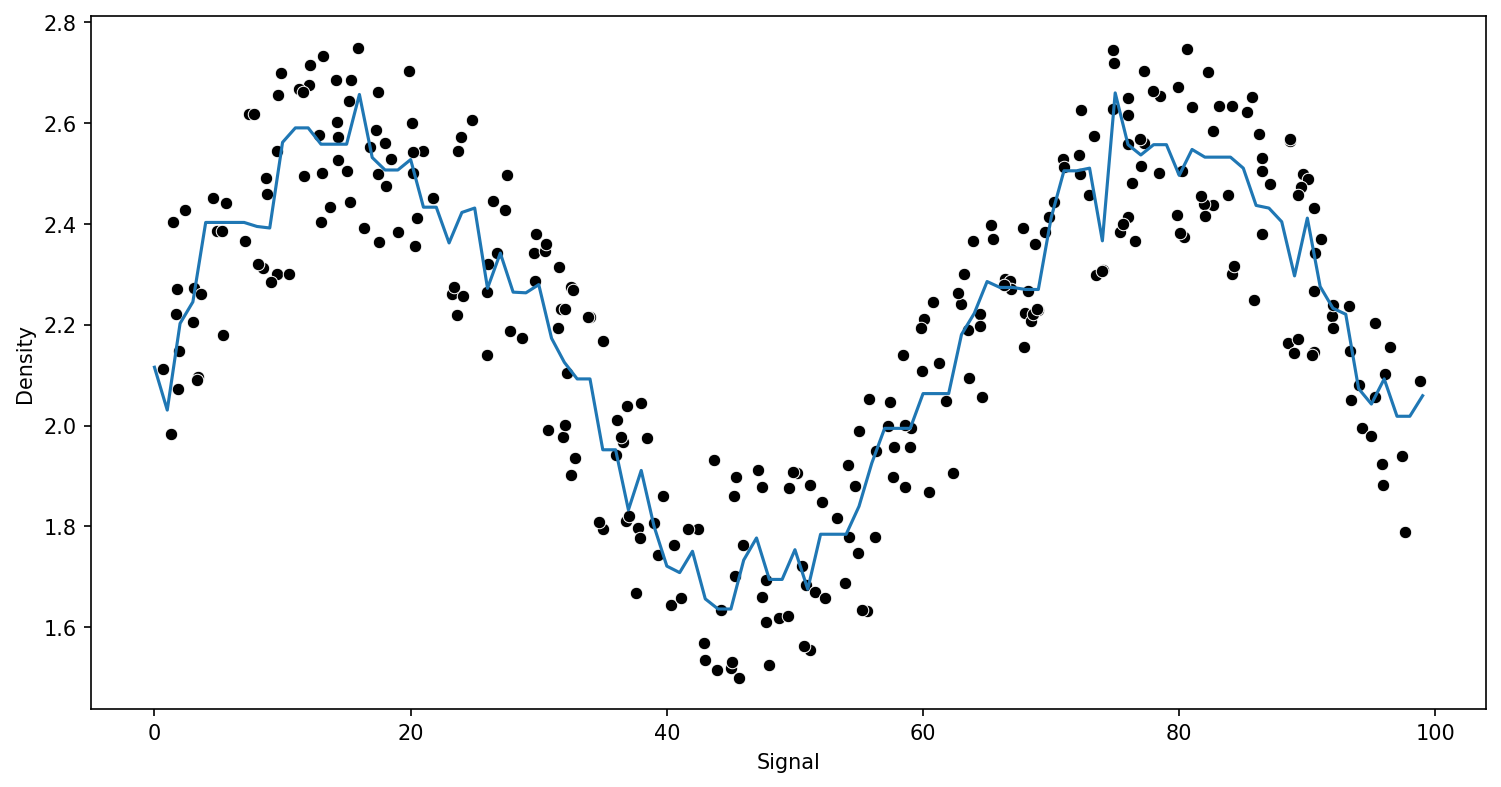

In [44]:
model = GradientBoostingRegressor()

run_model(model,X_train,y_train,X_test,y_test)

## Adaboost

In [45]:
from sklearn.ensemble import AdaBoostRegressor

MAE : 0.11318284854800689
RMSE : 0.13294148649584667


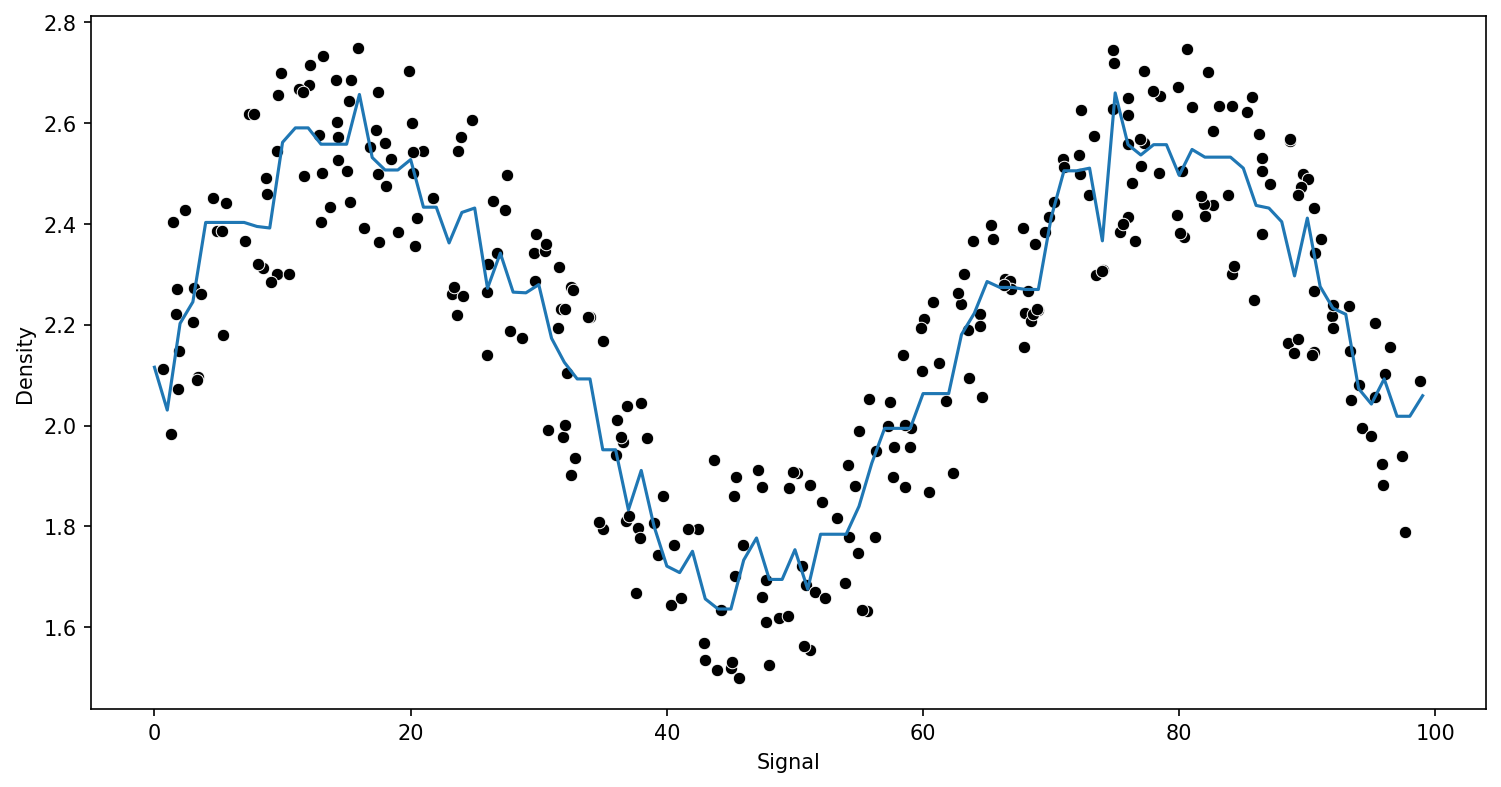

In [46]:
model = GradientBoostingRegressor()

run_model(model,X_train,y_train,X_test,y_test)

Boosting pikt minder ruis op...

----